# 03. The Bayesian structural time-series model, fitted by ADVI

The generative model is defined once in `nemforecastdemand.models.bsts`
and shared with notebook 04, which fits it by NUTS; everything that
differs between these notebooks is the inference algorithm. On demand
standardised over the fitting window:

$$
\begin{aligned}
y_t &\sim \mathcal{N}\!\left(\ell_t + x_t^\top \beta,\ \sigma_t^2\right),
&\log \sigma_t &= \gamma_0 + z_t^\top \gamma,\\
\ell_t &= \ell_{t-1} + b_{t-1} + \sigma_\ell\, \varepsilon^\ell_t,
&b_t &= \phi\, b_{t-1} + \sigma_b\, \varepsilon^b_t,
\qquad \varepsilon^\ell_t, \varepsilon^b_t \sim \mathcal{N}(0, 1),
\end{aligned}
$$

a stochastic local linear trend with damped slope, static regression on
the shared design $x_t$ (seasonal harmonics on local-clock phases,
temperature, dew point, irradiance, degree days, demand lags, holiday) and
a log-linear observation scale in a small variance design $z_t$ (three
daily harmonics plus degree days), so predictive spread follows the
covariates. Priors are weakly informative on the standardised scale:
half-normal innovation scales (0.1 and 0.01: trend moves slowly at half
hours), Beta(8, 2) damping, unit-scale Gaussian coefficients and tight
Gaussians on the variance head, whose exponential link punishes loose
priors with pathological geometry.

**The states are marginalised, not sampled.** Conditional on the
hyperparameters the trend is linear-Gaussian, so a Kalman filter inside
the likelihood integrates the state path out exactly and inference works
over roughly fifty hyperparameters however long the data. The naive
alternative, sampling every half hour's innovations as latent draws,
costs two dimensions per half hour, caps the affordable window at a few
weeks and defeats most of the toolkit; when it was attempted here, cold
NUTS did not complete 2,000 iterations in seventeen hours on the GPU and
the full-rank guide diverged, a dense Cholesky over thousands of
dimensions being underdetermined at any setting. Marginalisation removes
the dimension problem at the price of a sequential filter inside every
gradient, and the full training year is affordable for every inference
path. The same filter drives prediction: forecasts condition on all
demand up to each origin and simulate forward, with no per-origin
refitting.

**ADVI.** Automatic-differentiation variational inference maximises the
evidence lower bound over a Gaussian surrogate $q$ in the unconstrained
space, and the ELBO splits exactly as

$$ \mathrm{ELBO} = \underbrace{\mathbb{E}_q[\log p(y, \theta)]}_{\text{energy}}
   + \underbrace{\mathbb{H}[q]}_{\text{entropy}}, $$

energy rewarding mass where the model has it and entropy rewarding spread
(the energy term absorbs the Jacobian of the constraining transforms; the
entropy of a Gaussian surrogate is closed form). Watching the two parts
separately shows *how* the surrogate converges: under-dispersion appears
as entropy collapsing while energy still climbs. Two families are
fitted: **mean-field** (`AutoNormal`, independent Gaussians) and
**full-rank** (`AutoMultivariateNormal`, one joint Gaussian whose
covariance can carry the posterior correlations mean-field must
discard). At fifty-odd dimensions the full covariance is a
well-determined object.

In [1]:
import os

os.environ.setdefault("JAX_PLATFORMS", "cpu")  # notebook JAX work is light; leave the GPU to fits

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from nemforecastdemand.config import load_config
from nemforecastdemand.data.loaders import load_splits
from nemforecastdemand.evaluation.metrics import crps_gaussian, crps_samples
from nemforecastdemand.models import bsts
from nemforecastdemand.models.predict import variance_decomposition
from nemforecastdemand.plotting import fan_chart, palette, save_figure, setup_style
from nemforecastdemand.splits import rolling_origins
from nemforecastdemand.utils import load_artifact

setup_style()
cfg = load_config()
splits = load_splits(cfg.paths.processed)
panel = pd.concat([splits["train"], splits["validation"], splits["test"]])
max_lag = max(cfg.features.demand_lags)

fits = {
    kind: load_artifact(cfg.paths.artifacts / f"bsts_collapsed_vi_{kind}")
    for kind in ("meanfield", "fullrank")
}
test_origins = rolling_origins(splits["test"].index, panel.index, cfg.origins, cfg.horizon, max_lag)
fit_index = panel.index[panel.index < splits["test"].index[0]][max_lag:]
inputs = bsts.prepare_inputs(panel, cfg, fit_index)

SITES = tuple(s for s in bsts.HYPER_SITES if s not in ("level_init", "slope_init"))


def draws_of(kind: str) -> dict[str, np.ndarray]:
    """Hyperparameter draws with the marginalised init sites at their prior mean."""
    arrays = fits[kind][0]
    draws = {site: arrays[f"draw_{site}"] for site in SITES}
    zeros = np.zeros(draws["sigma_level"].shape[0], dtype=np.float32)
    return {**draws, "level_init": zeros, "slope_init": zeros}

/home/s95717/miniforge3/envs/nem-demand-forecast/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## ELBO convergence, decomposed

Both surrogates are optimised with Adam (20,000 steps, exponentially
decayed learning rate, gradient clipping); the ELBO is re-estimated with
64 particles at every checkpoint so the curves below are not just
single-sample noise.

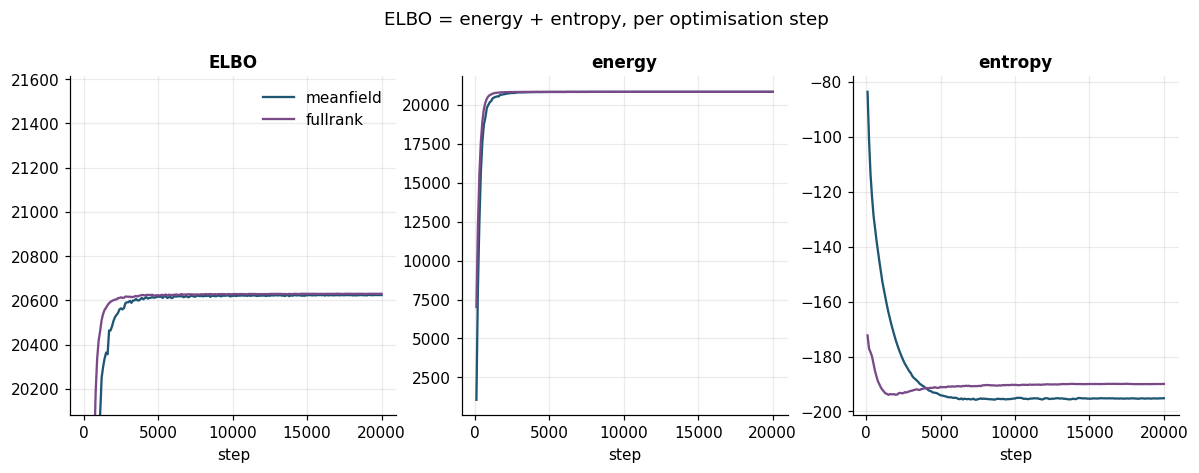

In [2]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colours = {"meanfield": palette("demand"), "fullrank": palette("accent")}
for kind, (arrays, _meta) in fits.items():
    axes[0].plot(arrays["elbo_steps"], arrays["elbo"], color=colours[kind], label=kind)
    axes[1].plot(arrays["elbo_steps"], arrays["energy"], color=colours[kind])
    axes[2].plot(arrays["elbo_steps"], arrays["entropy"], color=colours[kind])
for ax, title in zip(axes, ("ELBO", "energy", "entropy"), strict=True):
    ax.set_title(title)
    ax.set_xlabel("step")
axes[0].set_ylim(bottom=np.quantile(fits["meanfield"][0]["elbo"], 0.05))
axes[0].legend()
fig.suptitle("ELBO = energy + entropy, per optimisation step", y=1.03)
save_figure(fig, "elbo_decomposition", cfg.paths.figures)
plt.show()

In [3]:
def plateau_drift(elbo: np.ndarray, window: int = 20) -> str:
    """Relative ELBO drift between the last two checkpoint windows."""
    recent = elbo[-window:].mean()
    previous = elbo[-2 * window : -window].mean()
    return f"{abs(recent - previous) / abs(previous):.2%}"


pd.DataFrame(
    {
        kind: {
            "final ELBO": meta["final_elbo"],
            "final entropy": float(arrays["entropy"][-1]),
            "plateau drift, last 2k steps": plateau_drift(arrays["elbo"]),
            "fit seconds": meta["timings_seconds"]["fit_seconds"],
            "steps per second": meta["timings_seconds"]["steps_per_second"],
            "device": meta["device"],
        }
        for kind, (arrays, meta) in fits.items()
    }
).T

,final ELBO,final entropy,"plateau drift, last 2k steps",fit seconds,steps per second,device
meanfield,20623.925781,-195.176849,0.00%,3351.86493,5.966529,gpu
fullrank,20629.681641,-189.978302,0.00%,3358.002255,5.955624,gpu


The energy curves show whether both families find the same posterior
mass; the entropy curves are where a factorised Gaussian pays for the
correlations it discards, settling lower than a family that can carry
them. The decomposition makes that visible during training rather than
after the fact.

## Where mean-field under-estimates variance

With both surrogates fitted to the same model, the marginal standard
deviations of the hyperparameters compare directly, and the full-rank
covariance shows which correlations the mean-field family had to
discard. Which family is closer to the truth is settled by the NUTS
reference posterior in notebook 04.

In [4]:
hyper_names = ["sigma_level", "sigma_slope", "phi", "gamma0"]
rows = {}
for name in hyper_names:
    mf = fits["meanfield"][0][f"draw_{name}"]
    fr = fits["fullrank"][0][f"draw_{name}"]
    rows[name] = {
        "mean (MF)": mf.mean(),
        "sd (MF)": mf.std(),
        "sd (FR)": fr.std(),
        "sd ratio MF/FR": mf.std() / fr.std(),
    }
pd.DataFrame(rows).T.round(4)

,mean (MF),sd (MF),sd (FR),sd ratio MF/FR
sigma_level,0.0009,0.0007,0.0006,1.0298
sigma_slope,0.0477,0.0003,0.0004,0.7638
phi,0.7630,0.0057,0.0061,0.9300
gamma0,-4.6245,0.0157,0.0605,0.2591


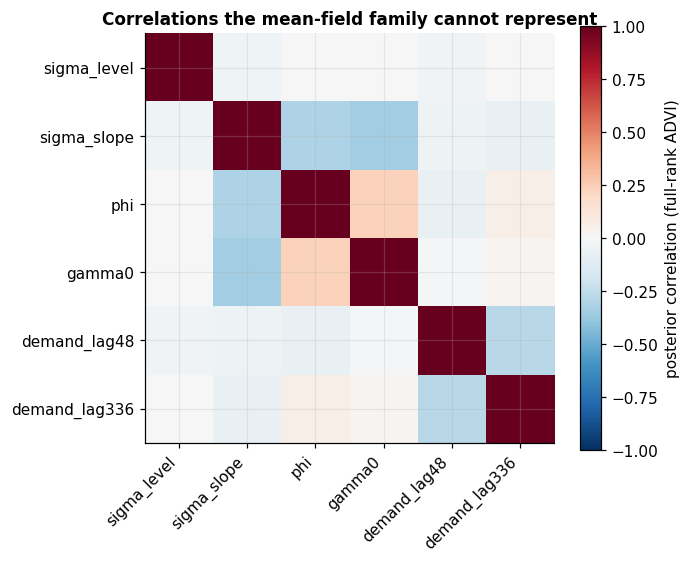

In [5]:
labels = ["sigma_level", "sigma_slope", "phi", "gamma0"]
draws_fr = np.column_stack([fits["fullrank"][0][f"draw_{name}"] for name in labels])
beta_fr = fits["fullrank"][0]["draw_beta"]
lag_cols = [i for i, c in enumerate(inputs.columns) if "lag" in c]
draws_fr = np.column_stack([draws_fr, beta_fr[:, lag_cols]])
labels = labels + [inputs.columns[i] for i in lag_cols]
corr = np.corrcoef(draws_fr.T)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
fig.colorbar(im, label="posterior correlation (full-rank ADVI)")
ax.set_title("Correlations the mean-field family cannot represent")
plt.show()

## The filtered trend and the learned variance profile

The level component absorbs what the regression cannot explain: slow
drift in the demand baseline across the year. The variance head learns
the daily rhythm of predictability, narrow bands in the small hours and
wide bands across the afternoon and evening, which is exactly what the
homoskedastic baseline could not express.

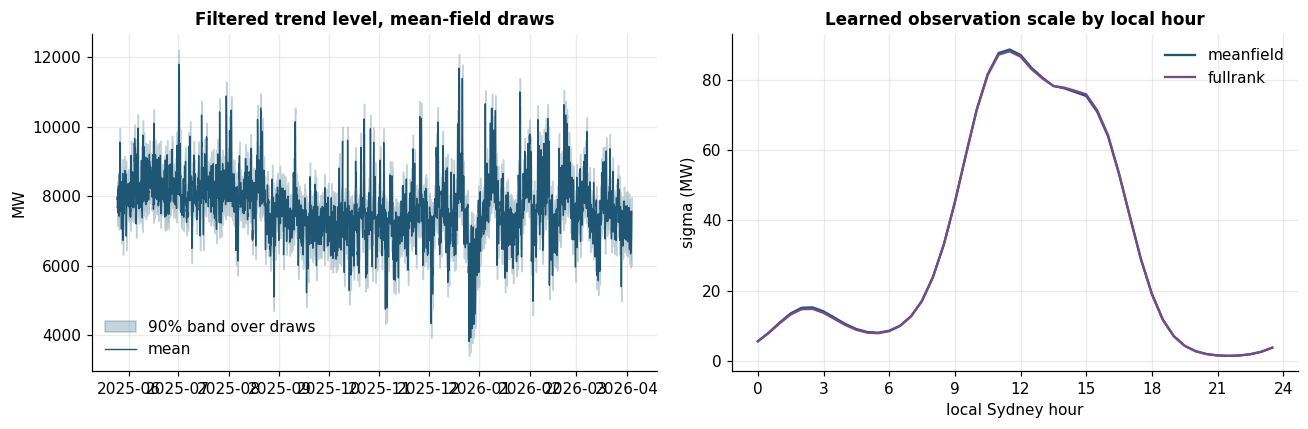

In [6]:
filtered_mean, _ = bsts.kalman_filter_states(
    draws_of("meanfield"), inputs.y, inputs.x_mean, inputs.x_var, cfg.bsts
)
level_mw = filtered_mean[:, :, 0] * inputs.y_scale + inputs.y_loc
times = fit_index.tz_convert("Australia/Brisbane")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].fill_between(
    times,
    np.quantile(level_mw, 0.05, axis=0),
    np.quantile(level_mw, 0.95, axis=0),
    color=palette("demand"),
    alpha=0.25,
    label="90% band over draws",
)
axes[0].plot(times, level_mw.mean(axis=0), color=palette("demand"), lw=0.9, label="mean")
axes[0].set_title("Filtered trend level, mean-field draws")
axes[0].set_ylabel("MW")
axes[0].legend()

local_hour = fit_index.tz_convert("Australia/Sydney")
hour_frac = local_hour.hour + local_hour.minute / 60
for kind in fits:
    arrays = fits[kind][0]
    gamma0 = arrays["draw_gamma0"][:, None]
    gamma = arrays["draw_gamma"]
    log_sigma = gamma0 + gamma @ inputs.x_var.T
    sigma_mw = np.exp(log_sigma) * inputs.y_scale
    profile = (
        pd.DataFrame({"hour": hour_frac, "sigma": sigma_mw.mean(axis=0)}).groupby("hour").mean()
    )
    axes[1].plot(profile.index, profile["sigma"], color=colours[kind], label=kind)
axes[1].set_title("Learned observation scale by local hour")
axes[1].set_xlabel("local Sydney hour")
axes[1].set_ylabel("sigma (MW)")
axes[1].set_xticks(np.arange(0, 25, 3))
axes[1].legend()
fig.tight_layout()
save_figure(fig, "bsts_trend_and_variance", cfg.paths.figures)
plt.show()

## Posterior predictive forecasts

Forecasts are Rao-Blackwellised: conditional on each hyperparameter draw
the model is linear-Gaussian, so a Kalman filter conditions on all demand
up to each origin and the horizon is then simulated forward, one jointly
coherent 48-step path per posterior draw. CRPS uses the energy-form
sample estimator (unit-tested against the analytic Gaussian form used for
the baseline).

In [7]:
arima_arrays, arima_meta = load_artifact(cfg.paths.artifacts / "arima")
y_test = fits["meanfield"][0]["y_test"]

crps_rows = {}
for kind, (arrays, _meta) in fits.items():
    per_origin = np.stack(
        [
            crps_samples(y_test[i], arrays["forecast_paths"][:, i, :]).mean()
            for i in range(y_test.shape[0])
        ]
    )
    crps_rows[f"BSTS ADVI {kind}"] = per_origin.mean()
crps_rows["ARIMA baseline"] = float(
    crps_gaussian(
        arima_arrays["y_test"], arima_arrays["forecast_mean"], arima_arrays["forecast_sd"]
    ).mean()
)
pd.Series(crps_rows, name="test CRPS (MW), archived forecast weather").to_frame().round(1)

,"test CRPS (MW), archived forecast weather"
BSTS ADVI meanfield,498.6
BSTS ADVI fullrank,496.8
ARIMA baseline,267.4


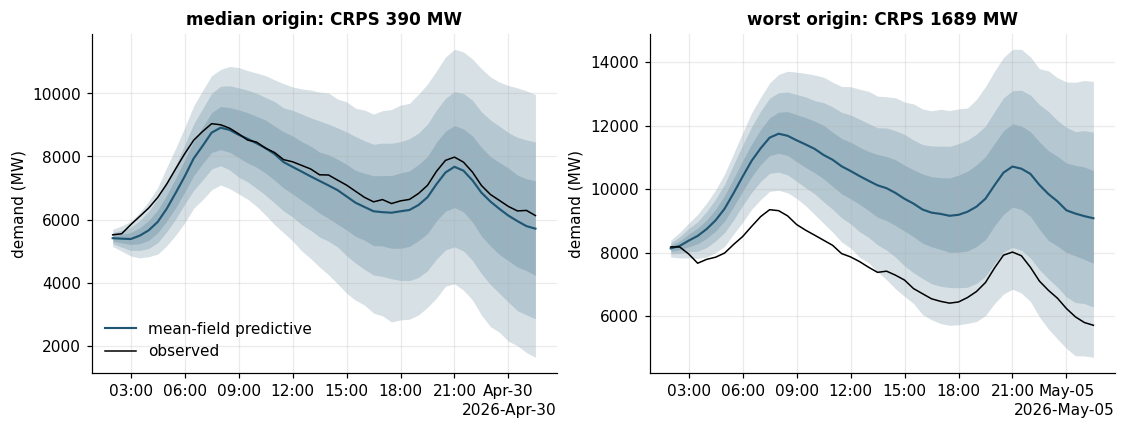

In [8]:
mf_paths = fits["meanfield"][0]["forecast_paths"]
daily_crps = np.stack(
    [crps_samples(y_test[i], mf_paths[:, i, :]).mean() for i in range(y_test.shape[0])]
)
typical = int(np.argsort(daily_crps)[len(daily_crps) // 2])
worst = int(daily_crps.argmax())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, pos, title in ((axes[0], typical, "median origin"), (axes[1], worst, "worst origin")):
    origin = test_origins[pos]
    index = pd.date_range(origin, periods=cfg.horizon, freq="30min")
    fan_chart(
        ax,
        index,
        samples=mf_paths[:, pos, :],
        colour=palette("demand"),
        label="mean-field predictive",
    )
    ax.plot(
        index.tz_convert("Australia/Brisbane"), y_test[pos], color="black", lw=1.0, label="observed"
    )
    ax.set_title(f"{title}: CRPS {daily_crps[pos]:.0f} MW")
    ax.set_ylabel("demand (MW)")
axes[0].legend()
save_figure(fig, "bsts_vi_fan_charts", cfg.paths.figures)
plt.show()

## Aleatoric against epistemic uncertainty

Because the model is linear-Gaussian given a hyperparameter draw, the
predictive variance splits exactly (law of total variance) into four
named sources: **parameter** (posterior spread of the per-draw
predictive means) and **state** (how well the level and slope at the
origin are pinned down) are epistemic, shrinking with more data;
**process** (future trend innovations) and **observation** (the
heteroskedastic noise floor) are aleatoric, irreducible under the model.
The split is computed analytically per draw, no simulation involved.

The fractions are diagnostic for the inference comparison too: a
surrogate that under-states posterior spread must report a smaller
epistemic share, so the gap between the two guides previews what the
NUTS adjudication in notebook 04 makes precise.

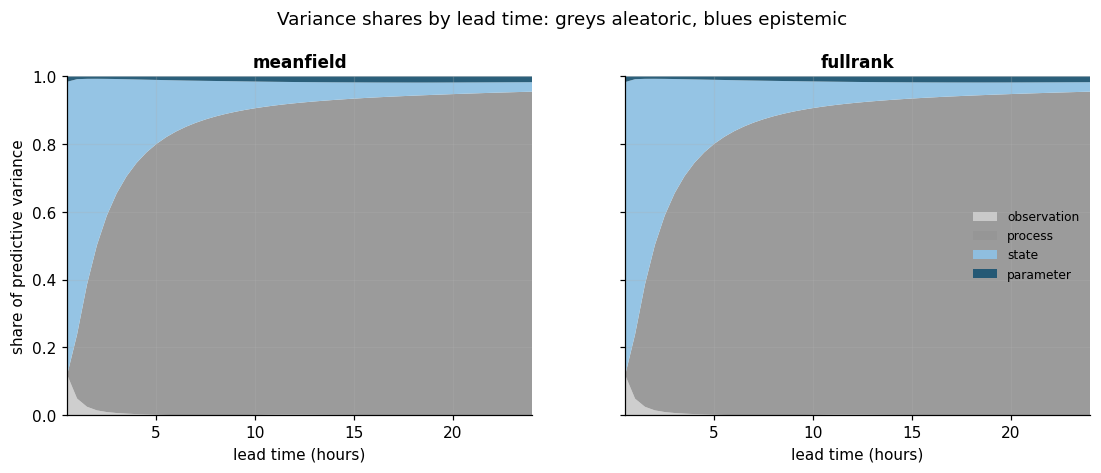

In [9]:
decomp = {
    kind: variance_decomposition(draws_of(kind), inputs, panel, cfg, test_origins) for kind in fits
}

component_order = ["observation", "process", "state", "parameter"]
component_colours = {
    "observation": "#cccccc",
    "process": "#969696",
    "state": "#8fc1e3",
    "parameter": "#1f5673",
}
hours = (np.arange(cfg.horizon) + 1) / 2
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, kind in zip(axes, fits, strict=True):
    parts = decomp[kind]
    total = sum(parts.values())
    shares = np.stack([(parts[name] / total).mean(axis=0) for name in component_order])
    ax.stackplot(
        hours,
        shares,
        labels=component_order,
        colors=[component_colours[n] for n in component_order],
        alpha=0.95,
    )
    ax.set_title(kind)
    ax.set_xlabel("lead time (hours)")
    ax.set_ylim(0, 1)
    ax.set_xlim(hours[0], hours[-1])
axes[0].set_ylabel("share of predictive variance")
axes[1].legend(loc="center right", fontsize=8)
fig.suptitle("Variance shares by lead time: greys aleatoric, blues epistemic", y=1.03)
save_figure(fig, "bsts_vi_variance_decomposition", cfg.paths.figures)
plt.show()

In [10]:
rows = {}
for kind in fits:
    parts = decomp[kind]
    total = sum(parts.values())
    rows[kind] = {f"{name} share": float((parts[name] / total).mean()) for name in component_order}
    rows[kind]["epistemic share"] = rows[kind]["state share"] + rows[kind]["parameter share"]
    rows[kind]["mean predictive sd (MW)"] = float(np.sqrt(total.mean()))
pd.DataFrame(rows).T.round(3)

,observation share,process share,state share,parameter share,epistemic share,mean predictive sd (MW)
meanfield,0.005,0.839,0.141,0.015,0.156,1490.692
fullrank,0.005,0.839,0.141,0.015,0.156,1487.797


## Cost

Fit and forecast wall-clock per surrogate (the forecast time covers all
test origins under all six weather variants, dominated by the one-off
Kalman filter pass over the posterior).

In [11]:
pd.DataFrame(
    {
        kind: {
            "fit (s)": meta["timings_seconds"]["fit_seconds"],
            "compile (s)": meta["timings_seconds"]["compile_seconds"],
            "forecast, all origins and variants (s)": meta["timings_seconds"]["predict_seconds"],
            "device": meta["device"],
        }
        for kind, (arrays, meta) in fits.items()
    }
).T

,fit (s),compile (s),"forecast, all origins and variants (s)",device
meanfield,3351.86493,3.18328,13.10359,gpu
fullrank,3358.002255,4.524519,5.502108,gpu


## Summary

- Both Gaussian families optimise stably on the marginalised geometry;
  the tables above quantify the entropy gap and the correlations the
  factorised family discards.
- The heteroskedastic head learns a plausible daily risk profile, and
  the exact variance decomposition names where predictive uncertainty
  comes from at each lead time.
- The predictive comparison against the classical baseline and the rest
  of the field is notebook 05's job; the adjudication of both surrogates
  against the NUTS reference posterior, including warm-start pricing,
  is notebook 04's.